In [15]:
from langgraph.graph import StateGraph , START,END
from langchain_groq import ChatGroq
from typing import TypedDict , List, Dict
from dotenv import load_dotenv

In [16]:
load_dotenv()

True

In [17]:
class CricketState(TypedDict):
    runs: int
    sixes: int
    fours: int
    balls: int 

    sr: float
    balls_per_boundary: float
    boundary_percent: float

In [18]:
graph = StateGraph(CricketState)

In [19]:
def calculate_sr(state: CricketState)->Dict:
    """calculates the StrikeRate of the Batsman"""
    runs = state['runs']
    balls = state['balls']

    strike_rate = (runs/balls) * 100
    return {"sr":strike_rate}

def cal_bpb(state: CricketState)->Dict:
    """calculates balls per boundary"""
    sixes = state["sixes"]
    fours = state["fours"]
    balls = state["balls"]

    bpb = balls/(sixes+fours)
    return {"balls_per_boundary":bpb}

def boundary_percent(state: CricketState)->Dict:
    """calcultes boundary percentage"""
    sixes = state['sixes']
    fours = state['fours']
    runs = state['runs']

    res = (((4*fours) + (6*sixes))/runs)*100
    return {"boundary_percent": res}
def summary(state: CricketState) -> Dict:
    """generates an overall summary or performance card"""
    
    # Determine performance grade
    sr = state["sr"]
    bpb = state["balls_per_boundary"]
    bp = state["boundary_percent"]
    
    # Performance grading logic
    if sr >= 150:
        grade = "Elite"
    elif sr >= 120:
        grade = "Excellent"
    elif sr >= 100:
        grade = "Good"
    elif sr >= 80:
        grade = "Average"
    else:
        grade = "Below Average"
    
    # Consistency indicator (lower BPB = more boundaries = aggressive)
    if bpb == float('inf'):
        aggression = "Boundary-less"
    elif bpb <= 6:
        aggression = "Highly Aggressive"
    elif bpb <= 10:
        aggression = "Aggressive"
    elif bpb <= 15:
        aggression = "Balanced"
    else:
        aggression = "Anchoring"
    
    return {
        "runs": state['runs'],
        "balls_faced": state['balls'],
        "sixes": state['sixes'],
        "fours": state['fours'],
        "strike_rate": sr,
        "balls_per_boundary": bpb,
        "boundary_percentage": bp,
        "grade": grade,
        "batting_style": aggression,
        "total_boundaries": state['sixes'] + state['fours']
    }

In [20]:
graph.add_node('Strike Rate',calculate_sr)
graph.add_node('balls per boundary', cal_bpb)
graph.add_node('boundary percentage', boundary_percent)
graph.add_node("summary", summary)


graph.add_edge(START,'Strike Rate')
graph.add_edge(START,'balls per boundary')
graph.add_edge(START,'boundary percentage')


graph.add_edge("Strike Rate", "summary")
graph.add_edge("balls per boundary", "summary")
graph.add_edge("boundary percentage", "summary")

graph.add_edge("summary", END)


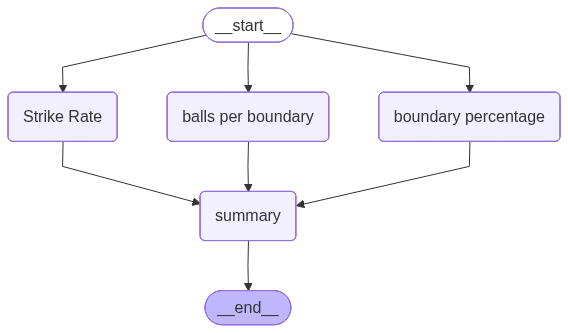

In [22]:
graph.compile()

In [23]:
app= graph.compile()
app.invoke({
    "runs": 85,
    "balls": 45,
    "sixes": 4,
    "fours": 8
})

{'runs': 85,
 'sixes': 4,
 'fours': 8,
 'balls': 45,
 'sr': 188.88888888888889,
 'balls_per_boundary': 3.75,
 'boundary_percent': 65.88235294117646}

In [21]:
player = {
    "runs": 85,
    "balls": 45,
    "sixes": 4,
    "fours": 8
}